# 01. Energy Consumption Forecasting: EDA & Preprocessing
This notebook focuses on exploring the "Appliances Energy Prediction" dataset. Our goal is to analyze temporal patterns, identify key influencers of energy consumption, and prepare the data for a Deep Learning model (PyTorch).

## 1. Environment Setup & Data Acquisition

In [4]:
import pandas as pd
import numpy as np

from pathlib import Path


In [5]:
#import dataset
data_path = Path.cwd().parent / 'data' / 'raw' / 'energydata_complete.csv'
if data_path.exists():
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully")
else:
    print("Path data does not exist")

Dataset loaded successfully


## 2.Explore dataset

In [3]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [5]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [6]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [68]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
df.sort_index(inplace=True)

In [69]:
# Check if the time gaps are all exactly 10 minutes
time_diffs = df.index.to_series().diff().value_counts()
print("Time Step Distribution:\n", time_diffs)

Time Step Distribution:
 date
0 days 00:10:00    19734
Name: count, dtype: int64


In [70]:
df.tail(1)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,
2016-05-27 18:00:00,430,10,25.5,46.6,25.264286,42.971429,26.823333,41.156667,24.7,45.963333,...,23.2,46.845,22.2,755.2,57.0,4.0,27.0,13.2,34.118851,34.118851


In each 10 minutes we have a new observation

### Analysis & Visualization (time series, distributions, ACF/PACF, correlation)

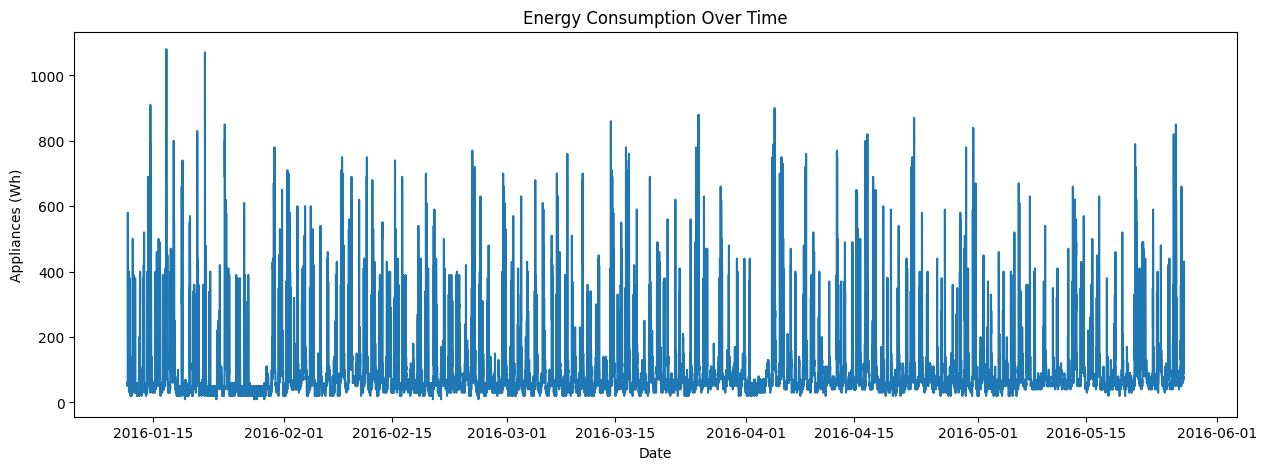

In [71]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df['Appliances'])
plt.title('Energy Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Appliances (Wh)')
plt.show()

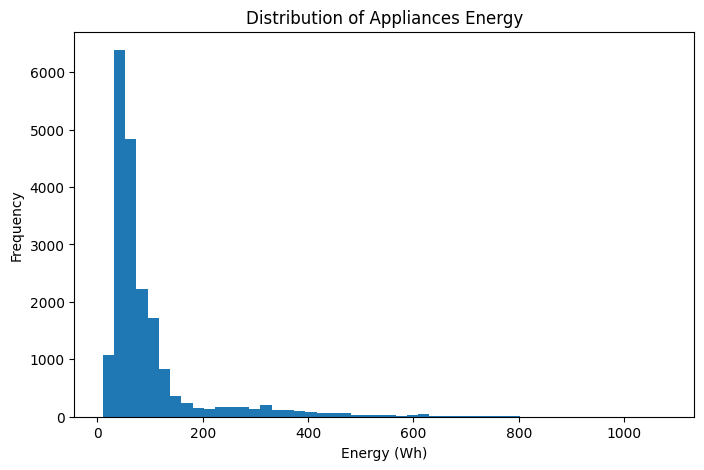

In [72]:
plt.figure(figsize=(8,5))
plt.hist(df['Appliances'], bins=50)
plt.title('Distribution of Appliances Energy')
plt.xlabel('Energy (Wh)')
plt.ylabel('Frequency')
plt.show()

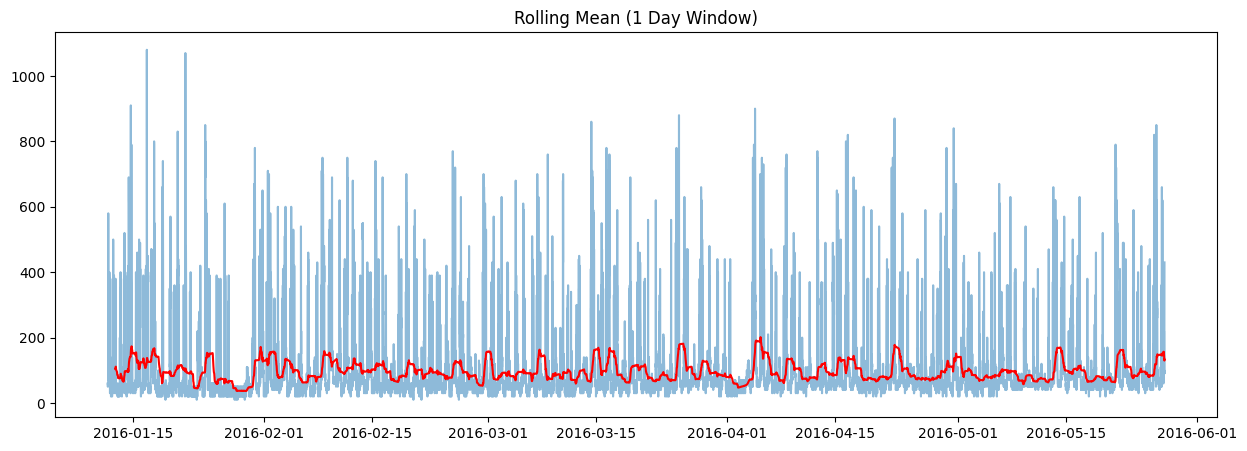

In [73]:
rolling_mean = df['Appliances'].rolling(window=144).mean()

plt.figure(figsize=(15,5))
plt.plot(df['Appliances'], alpha=0.5)
plt.plot(rolling_mean, color='red')
plt.title('Rolling Mean (1 Day Window)')
plt.show()

In [74]:
df["day"] = df.index.day
df["month"] = df.index.month


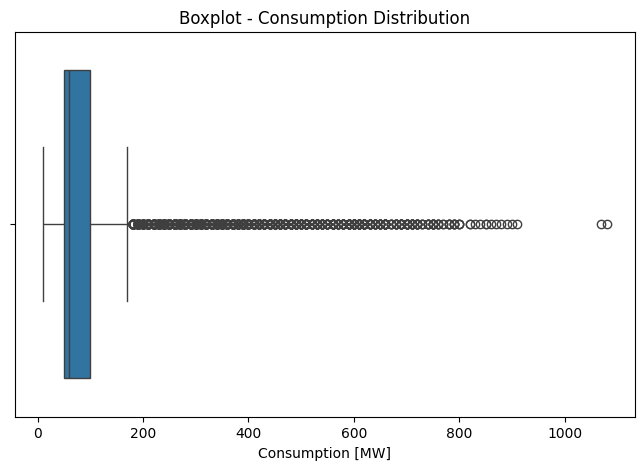

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Appliances')
plt.xlabel('Consumption [MW]')
plt.title(f'Boxplot - Consumption Distribution');

Text(0.5, 0, 'Month')

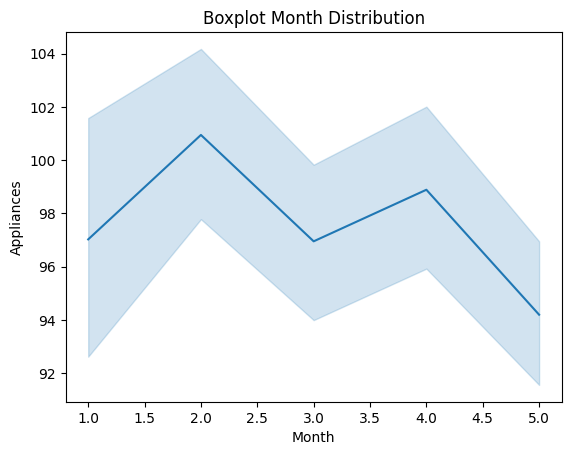

In [76]:
plt.title(f'Boxplot Month Distribution');
sns.lineplot(x='month', y='Appliances', data=df)
plt.ylabel('Appliances')
plt.xlabel('Month')

Text(0.5, 0, 'Hour')

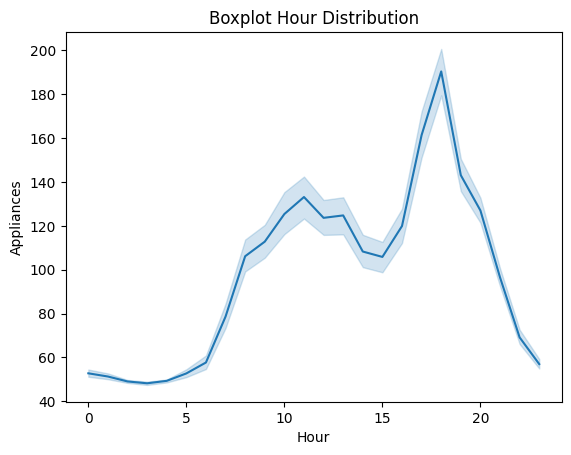

In [78]:
plt.title(f'Boxplot Hour Distribution');
df['hour']   = df.index.hour
plt.xlabel('Hour')

sns.lineplot(x='hour', y='Appliances', data = df)
plt.ylabel('Appliances')
plt.xlabel('Hour')


- ACF :measures the relationship between the current energy usage and its past.
=> tells us if the data has a trend
- PACF: It measures the relationship between two times by removing the influence of everything that happened in between
=> tells us exactly how many lags to use as inputs for our AI.


<Figure size 1400x800 with 0 Axes>

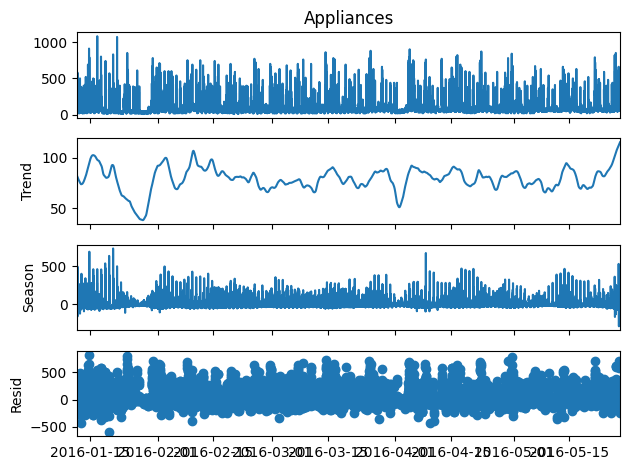

In [79]:
from statsmodels.tsa.seasonal import STL
plt.figure(figsize=(14,8))
stl = STL(df['Appliances'], period=144, robust=True)
res = stl.fit()
res.plot()
plt.show()

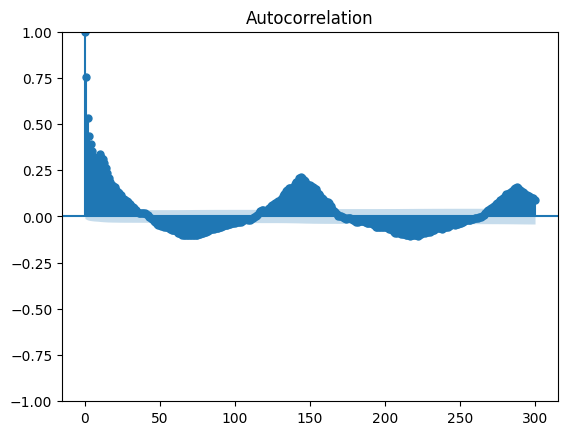

In [80]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Appliances'], lags=300)
plt.show()

- Strong Positive Autocorrelation at Low Lags
- Slow Decay of Autocorrelation
The ACF values decrease gradually rather than dropping quickly toward zero.
This slow decay suggests that the series is non-stationary, meaning the statistical properties (mean and variance) are not constant over time.
- Clear Seasonal Pattern
The ACF exhibits repeating peaks around lag 144 and its multiples.
Since the data is recorded every 10 minutes, 144 lags correspond to 24 hours.
=>This confirms the presence of strong daily seasonality in energy consumption.


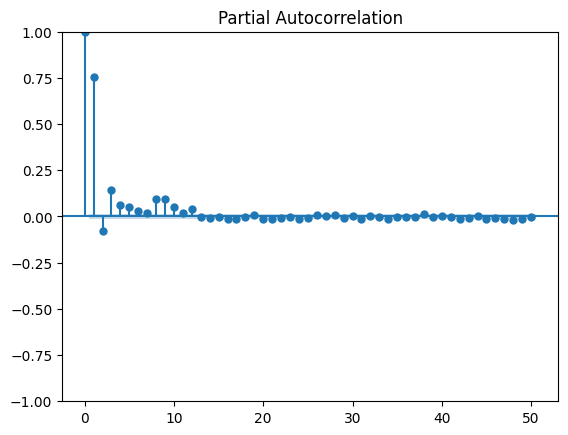

In [81]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['Appliances'], lags=50)
plt.show()

Lag 1 (~0.75): The strongest predictor of energy use right now is what the energy use was 10 minutes ago.

Lag 2: There is still a small significant relationship here.

The "Cut-off": After Lag 2 or 3, the bars crash into the "noise".

<Axes: >

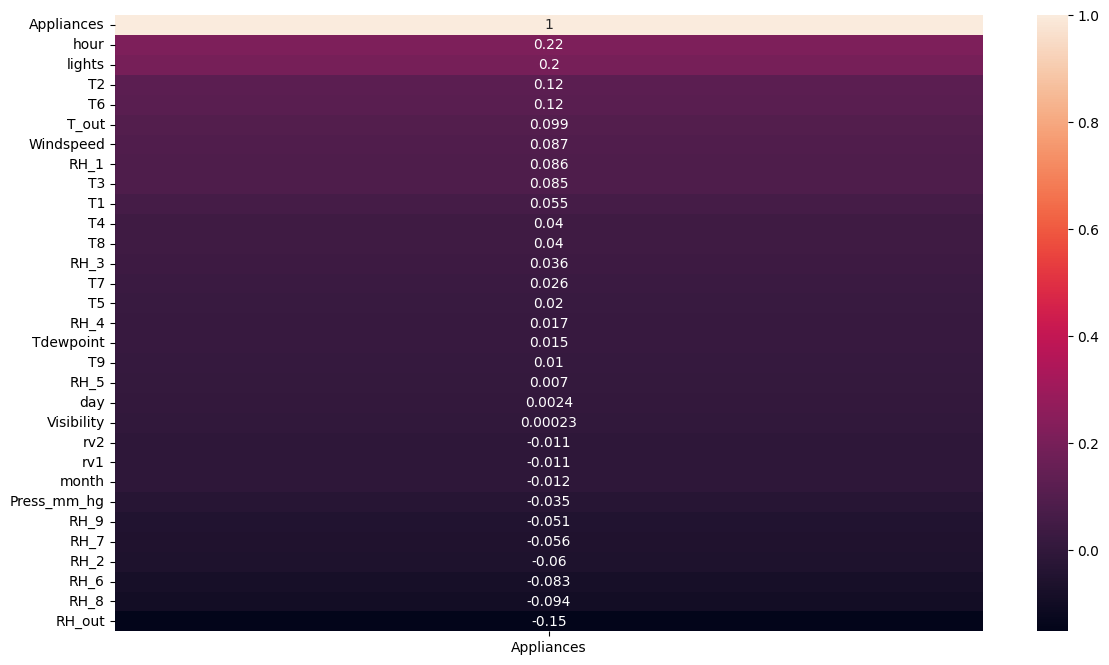

In [82]:
plt.figure(figsize=(14,8))
corr = df.corr()
sns.heatmap(corr[['Appliances']].sort_values('Appliances', ascending=False), annot=True)

### Feature Engineering (lags, engineered features, selection)

In [83]:
result = adfuller(df['Appliances'].dropna())
print(f'ADF Statistic : {result[0]:.4f}')
print(f'p-value       : {result[1]:.4f}')
print(f'Lags used     : {result[2]}')

if result[1] < 0.05:
    print("\n✅ STATIONARY — no differencing needed")
else:
    print("\n⚠️ NON-STATIONARY — consider differencing")

ADF Statistic : -21.6164
p-value       : 0.0000
Lags used     : 11

✅ STATIONARY — no differencing needed


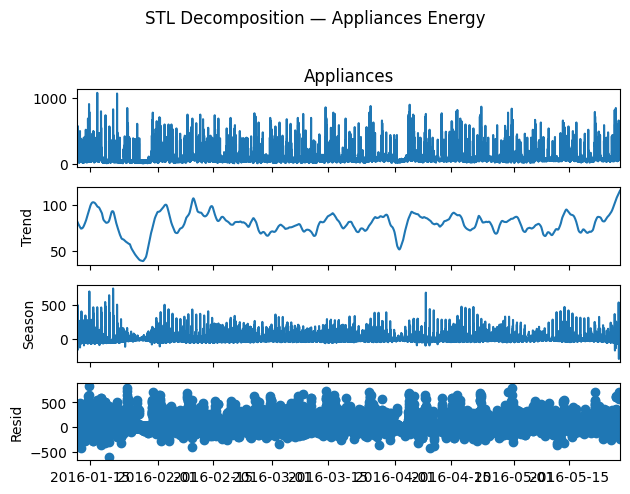

Trend    variance: 132.37
Seasonal variance: 2896.70
Residual variance: 7750.71


In [84]:

stl = STL(df['Appliances'], period=144, robust=True)
res = stl.fit()
res.plot()
plt.suptitle('STL Decomposition — Appliances Energy', y=1.02)
plt.tight_layout()
plt.show()

print(f"Trend    variance: {res.trend.var():.2f}")
print(f"Seasonal variance: {res.seasonal.var():.2f}")
print(f"Residual variance: {res.resid.var():.2f}")

In [94]:
df['dayofweek']   = df.index.dayofweek
df['month']       = df.index.month
df['is_weekend']  = df['dayofweek'].isin([5, 6]).astype(int)
df['is_night']    = df['hour'].isin(range(0, 6)).astype(int)
df['is_peak']     = df['hour'].isin(range(17, 21)).astype(int)

# Cyclical encoding (better than raw hour for neural nets)
df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
df['day_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)

print("✅ Time features created")
print(df[['hour','dayofweek','is_weekend','is_peak','hour_sin','hour_cos']].head(3))

✅ Time features created
                     hour  dayofweek  is_weekend  is_peak  hour_sin  hour_cos
date                                                                         
2016-01-11 17:00:00    17          0           0        1 -0.965926 -0.258819
2016-01-11 17:10:00    17          0           0        1 -0.965926 -0.258819
2016-01-11 17:20:00    17          0           0        1 -0.965926 -0.258819


In [97]:
lags = [1, 2, 3, 6, 12, 24, 144]
for lag in lags:
    df[f'lag_{lag}'] = df['Appliances'].shift(lag)

print("✅ Lag features created:", [f'lag_{l}' for l in lags])

✅ Lag features created: ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'lag_24', 'lag_144']


In [98]:
windows = [6, 12, 24, 144]
for w in windows:
    df[f'rolling_mean_{w}'] = df['Appliances'].rolling(w).mean()
    df[f'rolling_std_{w}']  = df['Appliances'].rolling(w).std()

# Rolling min/max for 24 steps (captures daily range)
df['rolling_min_24']  = df['Appliances'].rolling(24).min()
df['rolling_max_24']  = df['Appliances'].rolling(24).max()
df['rolling_range_24']= df['rolling_max_24'] - df['rolling_min_24']

print("✅ Rolling features created")
print([c for c in df.columns if 'rolling' in c])


✅ Rolling features created
['rolling_mean_6', 'rolling_std_6', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_144', 'rolling_std_144', 'rolling_min_24', 'rolling_max_24', 'rolling_range_24']


In [99]:
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f"✅ Dropped {before - after} NaN rows (from lags/rolling)")
print(f"Final shape: {df.shape}")

✅ Dropped 144 NaN rows (from lags/rolling)
Final shape: (19591, 57)


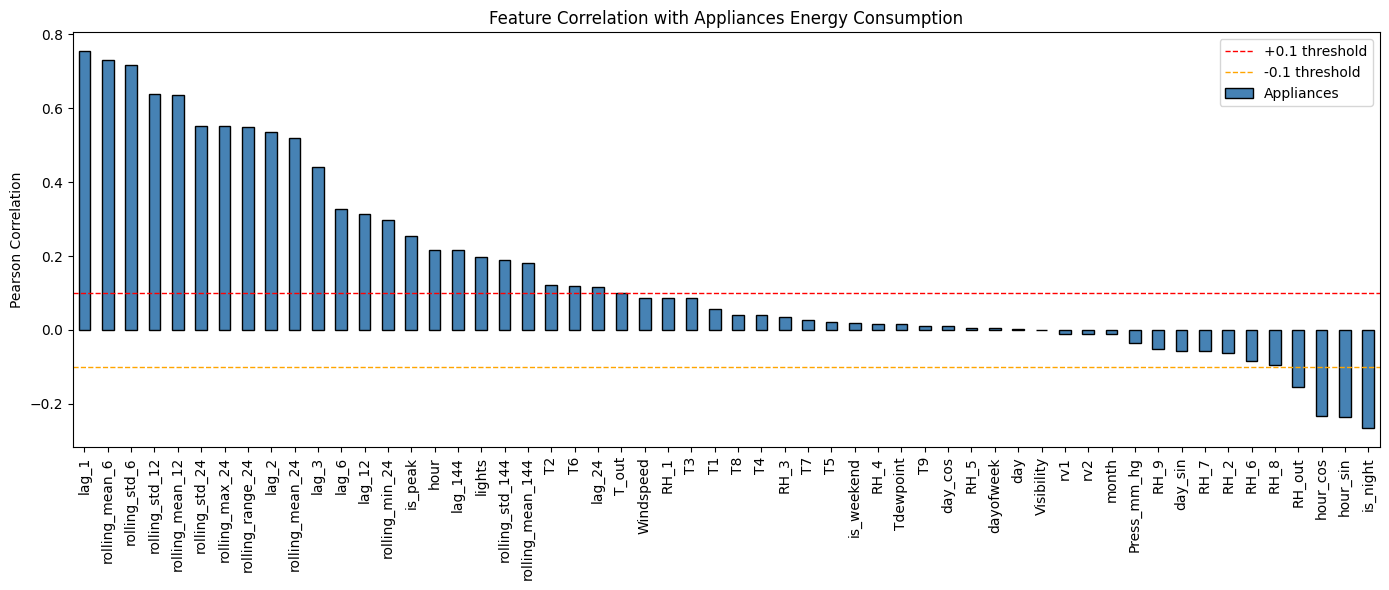


✅ Selected 29 features (|corr| > 0.09):
  lag_1                          → 0.754
  rolling_mean_6                 → 0.731
  rolling_std_6                  → 0.716
  rolling_std_12                 → 0.640
  rolling_mean_12                → 0.637
  rolling_std_24                 → 0.553
  rolling_max_24                 → 0.551
  rolling_range_24               → 0.550
  lag_2                          → 0.536
  rolling_mean_24                → 0.520
  lag_3                          → 0.441
  lag_6                          → 0.327
  lag_12                         → 0.313
  rolling_min_24                 → 0.298
  is_peak                        → 0.253
  hour                           → 0.217
  lag_144                        → 0.217
  lights                         → 0.197
  rolling_std_144                → 0.190
  rolling_mean_144               → 0.182
  T2                             → 0.120
  T6                             → 0.118
  lag_24                         → 0.116
  T_out         

In [116]:
corr_target = df.corr()['Appliances'].sort_values(ascending=False)

# Plot
plt.figure(figsize=(14, 6))
corr_target.drop('Appliances').plot(kind='bar', color='steelblue', edgecolor='black')
plt.axhline(y=0.1,  color='red',   linestyle='--', linewidth=1, label='+0.1 threshold')
plt.axhline(y=-0.1, color='orange',linestyle='--', linewidth=1, label='-0.1 threshold')
plt.title('Feature Correlation with Appliances Energy Consumption')
plt.ylabel('Pearson Correlation')
plt.legend()
plt.tight_layout()
plt.show()

# Select features above threshold
THRESHOLD = 0.09
selected_features = corr_target[
    (abs(corr_target) > THRESHOLD) & (corr_target.index != 'Appliances')
].index.tolist()

print(f"\n✅ Selected {len(selected_features)} features (|corr| > {THRESHOLD}):")
for f in selected_features:
    print(f"  {f:30s} → {corr_target[f]:.3f}")

In [117]:
FEATURES = selected_features
TARGET   = 'Appliances'

df_model = df[FEATURES + [TARGET]].copy()

print("✅ Final dataset ready for modeling")
print(f"   Shape   : {df_model.shape}")
print(f"   Features: {len(FEATURES)}")
print(f"   Target  : {TARGET}")
print(f"\nDate range: {df_model.index.min()} → {df_model.index.max()}")
df_model.head(3)

✅ Final dataset ready for modeling
   Shape   : (19591, 30)
   Features: 29
   Target  : Appliances

Date range: 2016-01-12 17:00:00 → 2016-05-27 18:00:00


,lag_1,rolling_mean_6,rolling_std_6,rolling_std_12,rolling_mean_12,rolling_std_24,rolling_max_24,rolling_range_24,lag_2,rolling_mean_24,...,T2,T6,lag_24,T_out,RH_8,RH_out,hour_cos,hour_sin,is_night,Appliances
date,,,,,,,,,,,,,,,,,,,,,
2016-01-12 17:00:00,40.0,45.000000,8.366600,9.003366,39.166667,92.139426,370.0,340.0,40.0,91.250000,...,19.00,6.156667,60.0,6.500000,45.790000,75.000000,-0.258819,-0.965926,0,60
2016-01-12 17:10:00,60.0,48.333333,9.831921,10.836247,40.833333,81.968534,370.0,340.0,40.0,81.666667,...,19.00,6.090000,290.0,6.316667,45.808333,76.666667,-0.258819,-0.965926,0,60
2016-01-12 17:20:00,60.0,75.000000,66.858059,50.000000,55.000000,85.567162,370.0,340.0,60.0,85.000000,...,18.99,6.090000,130.0,6.133333,45.900000,78.333333,-0.258819,-0.965926,0,210


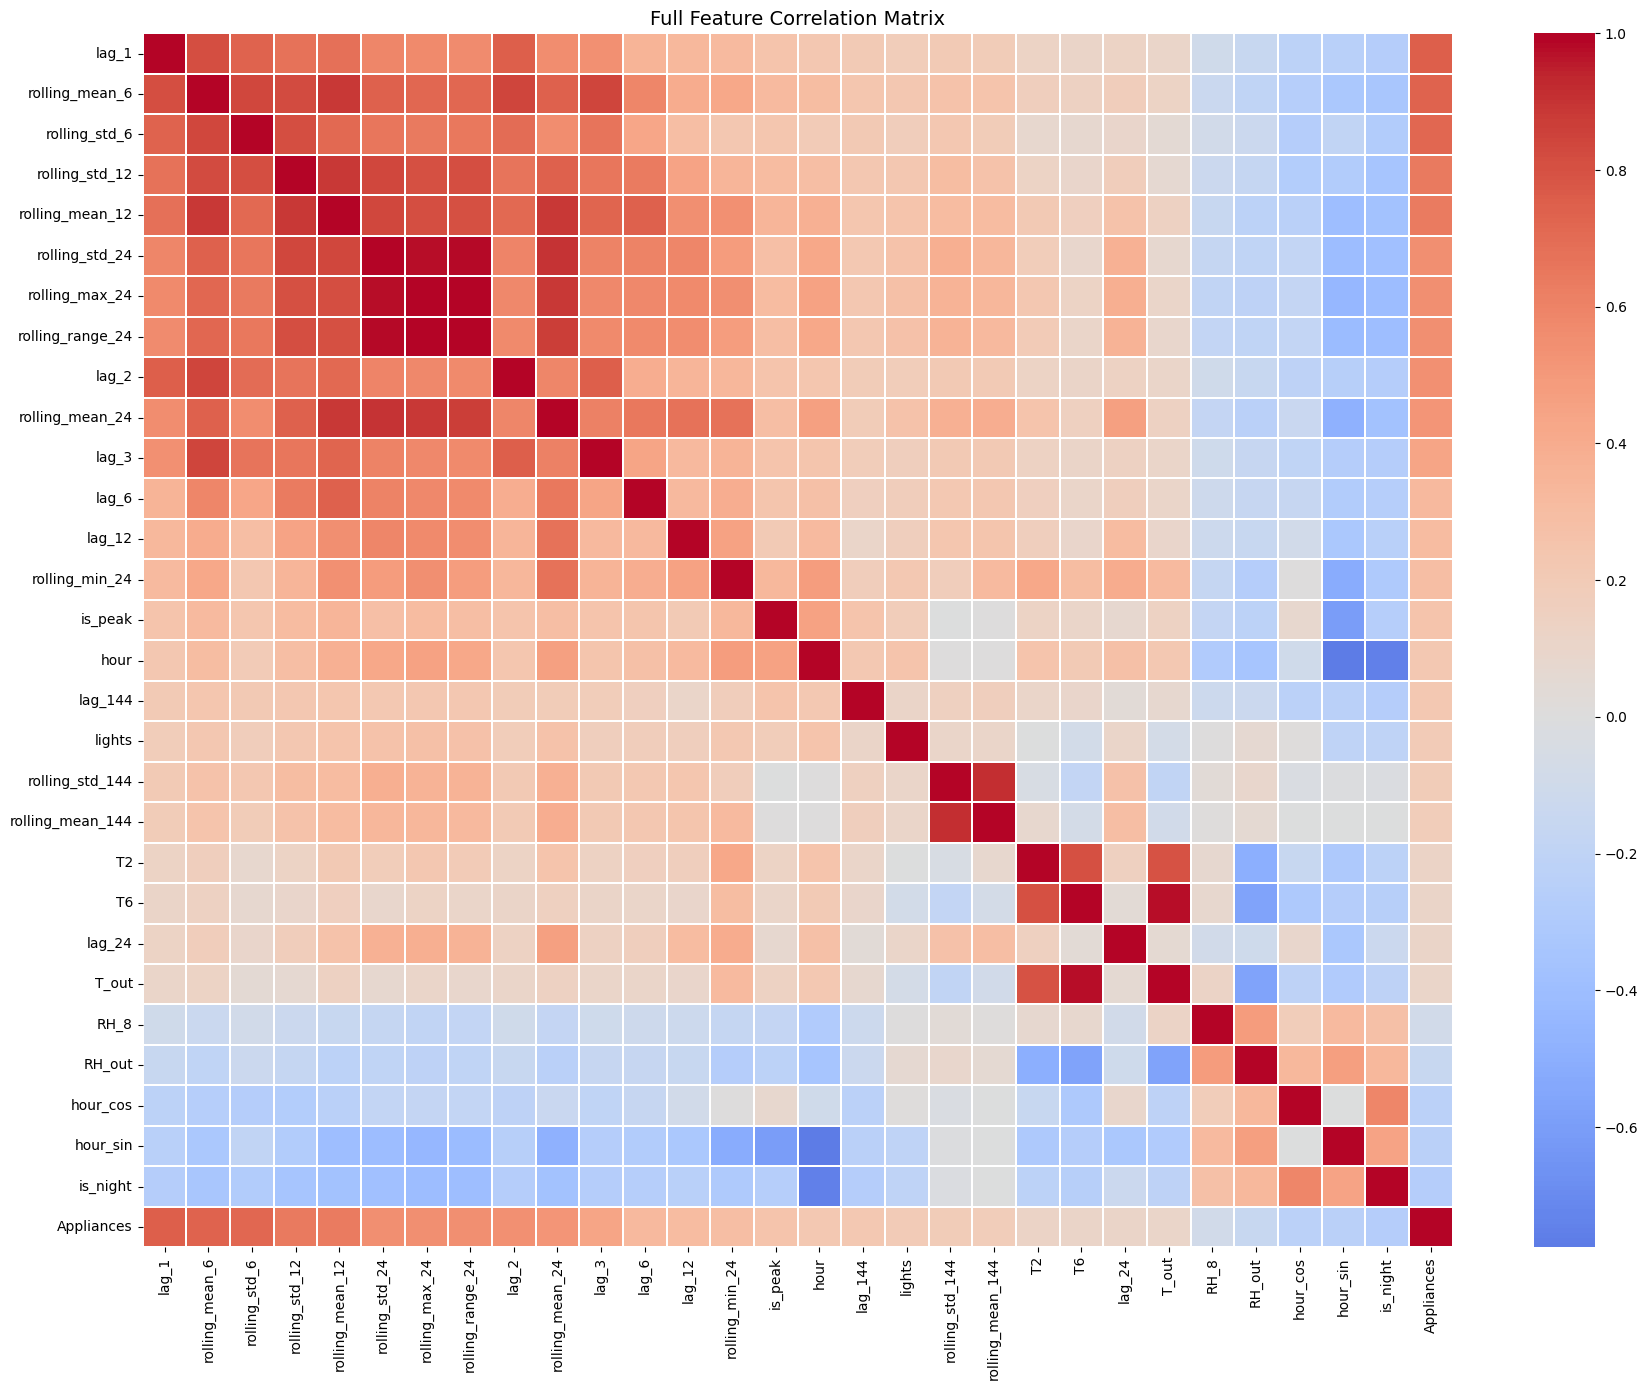

In [118]:
plt.figure(figsize=(18, 14))
sns.heatmap(
    df_model.corr(),
    cmap='coolwarm',
    center=0,
    annot=False,
    linewidths=0.3
)
plt.title('Full Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### Building models 



#### 1) Sarima model 

##### Split data 

In [122]:
series = df['Appliances'].copy()

n         = len(series)
train_end = int(n * 0.85)  

train_series = series.iloc[:train_end]
test_series  = series.iloc[train_end:]

print(f"Total  : {n:,}")
print(f"Train  : {len(train_series):,}")
print(f"Test   : {len(test_series):,}")
print(f"\nTrain period: {train_series.index[0]} → {train_series.index[-1]}")
print(f"Test period : {test_series.index[0]} → {test_series.index[-1]}")

Total  : 19,591
Train  : 16,652
Test   : 2,939

Train period: 2016-01-12 17:00:00 → 2016-05-07 08:10:00
Test period : 2016-05-07 08:20:00 → 2016-05-27 18:00:00


##### Baseline

In [138]:
test_series.shift(1)

date
2016-05-07 08:20:00      NaN
2016-05-07 08:30:00    100.0
2016-05-07 08:40:00    120.0
2016-05-07 08:50:00    200.0
2016-05-07 09:00:00    130.0
                       ...  
2016-05-27 17:20:00     90.0
2016-05-27 17:30:00    100.0
2016-05-27 17:40:00     90.0
2016-05-27 17:50:00    270.0
2016-05-27 18:00:00    420.0
Name: Appliances, Length: 2939, dtype: float64

In [133]:
test_series.iloc[1:]

date
2016-05-07 08:30:00    120
2016-05-07 08:40:00    200
2016-05-07 08:50:00    130
2016-05-07 09:00:00     80
2016-05-07 09:10:00    210
                      ... 
2016-05-27 17:20:00    100
2016-05-27 17:30:00     90
2016-05-27 17:40:00    270
2016-05-27 17:50:00    420
2016-05-27 18:00:00    430
Name: Appliances, Length: 2938, dtype: int64

In [124]:
train_series.iloc[-1:].values.repeat(len(test_series))

array([90, 90, 90, ..., 90, 90, 90], shape=(2939,))

In [156]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
# ============================================================
# CELL 4 — Persistence Baseline (10-min)
# ============================================================
baseline_preds   = test_series.shift(1).dropna()
baseline_actuals = test_series.iloc[1:]

base_mae  = mean_absolute_error(baseline_actuals, baseline_preds)
base_rmse = np.sqrt(mean_squared_error(baseline_actuals, baseline_preds))
base_mape = np.mean(np.abs((baseline_actuals - baseline_preds) /
                   (baseline_actuals + 1e-8))) * 100

print("="*40)
print("📊 PERSISTENCE BASELINE (10-min)")
print("="*40)
print(f"  MAE  : {base_mae:.2f}  Wh")
print(f"  RMSE : {base_rmse:.2f} Wh")
print(f"  MAPE : {base_mape:.2f} %")
print("="*40)

📊 PERSISTENCE BASELINE (10-min)
  MAE  : 26.73  Wh
  RMSE : 66.80 Wh
  MAPE : 21.51 %


###### SARIMA Order Selection

Based on your ACF/PACF analysis:
 - p=1 (PACF cuts off after lag 1)
 - d=0 (ADF confirmed stationary)
 - q=1 (ACF decay)
 - P=1, D=0, Q=1, s=144 (daily seasonality)

In [146]:
train_subset = train_hourly.iloc[-500:]

sarima_model = SARIMAX(
    train_subset,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),  # ← s=24 not 144
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)
print("✅ SARIMA trained!")

✅ SARIMA trained!


In [147]:
n_test         = len(test_hourly)
sarima_preds   = sarima_result.forecast(steps=n_test)
sarima_actuals = test_hourly.values

sarima_mae  = mean_absolute_error(sarima_actuals, sarima_preds)
sarima_rmse = np.sqrt(mean_squared_error(sarima_actuals, sarima_preds))
sarima_mape = np.mean(np.abs((sarima_actuals - sarima_preds) /
                     (sarima_actuals + 1e-8))) * 100

print("="*40)
print("📊 SARIMA RESULTS")
print("="*40)
print(f"  MAE  : {sarima_mae:.2f}  Wh")
print(f"  RMSE : {sarima_rmse:.2f} Wh")
print(f"  MAPE : {sarima_mape:.2f} %")
print("="*40)

📊 SARIMA RESULTS
  MAE  : 45.47  Wh
  RMSE : 76.16 Wh
  MAPE : 38.89 %


=> SARIMA(1,0,1)(1,0,1,24) failed to outperform even the naive persistence baseline — achieving RMSE of 76.16 vs 60.65 — highlighting the limitations of linear univariate models on noisy, spiky appliance consumption data. This motivates the use of a multivariate deep learning approach.

###### 2) Hot winter

In [152]:
# ============================================================
# CELL 1 — Holt-Winters on 10-min data (fast trick)
# ============================================================
# Instead of s=144 full → use shorter train window
# 144 × 14 days = 2016 points → enough to capture daily pattern

train_hw = train_series.iloc[-2016:]  # last 14 days of 10-min data

print(f"Train subset : {len(train_hw):,} rows")
print(f"Period       : {train_hw.index[0]} → {train_hw.index[-1]}")
print(f"Seasonal period: 144 (144 × 10min = 24h) ✅")

Train subset : 2,016 rows
Period       : 2016-04-23 08:20:00 → 2016-05-07 08:10:00
Seasonal period: 144 (144 × 10min = 24h) ✅


In [154]:
# ============================================================
# CELL 2 — Train Holt-Winters (10-min, s=144)
# ============================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train_hw,
    trend='add',
    seasonal='add',
    seasonal_periods=144,       # ← back to 144 ✅
    initialization_method='estimated'
)

hw_result = hw_model.fit(optimized=True)
print("✅ Holt-Winters trained on 10-min data!")
print(f"   Alpha (level)    : {hw_result.params['smoothing_level']:.4f}")
print(f"   Beta  (trend)    : {hw_result.params['smoothing_trend']:.4f}")
print(f"   Gamma (seasonal) : {hw_result.params['smoothing_seasonal']:.4f}")

c:\February_mini_project\energy_project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


✅ Holt-Winters trained on 10-min data!
   Alpha (level)    : 1.0000
   Beta  (trend)    : 0.0007
   Gamma (seasonal) : 0.0000


In [159]:
# ============================================================
# FIXED CELL — Holt-Winters correct evaluation
# ============================================================

# Correct n_test from 10-min test series
n_test_10min = len(test_series)
print(f"n_test (10-min): {n_test_10min}")

# Reforecast with correct length
hw_preds   = hw_result.forecast(steps=n_test_10min)
hw_actuals = test_series.values

# Align lengths
min_len    = min(len(hw_preds), len(hw_actuals))
hw_preds   = hw_preds[:min_len]
hw_actuals = hw_actuals[:min_len]

hw_mae  = mean_absolute_error(hw_actuals, hw_preds)
hw_rmse = np.sqrt(mean_squared_error(hw_actuals, hw_preds))
hw_mape = np.mean(np.abs((hw_actuals - hw_preds) /
                 (hw_actuals + 1e-8))) * 100

print("="*40)
print("📊 HOLT-WINTERS (10-min) FIXED")
print("="*40)
print(f"  MAE  : {hw_mae:.2f}  Wh")
print(f"  RMSE : {hw_rmse:.2f} Wh")
print(f"  MAPE : {hw_mape:.2f} %")
print("="*40)

n_test (10-min): 2939
📊 HOLT-WINTERS (10-min) FIXED
  MAE  : 1041.00  Wh
  RMSE : 1209.51 Wh
  MAPE : 1427.39 %


In [1]:
# ============================================================
# DIAGNOSIS CELL — run this first
# ============================================================
print("Train subset stats:")
print(train_hw.describe())
print(f"\nAny NaN in train: {train_hw.isna().sum()}")
print(f"Any NaN in test : {test_series.isna().sum()}")
print(f"\nTrain min: {train_hw.min():.2f}")
print(f"Train max: {train_hw.max():.2f}")
print(f"Test  min: {test_series.min():.2f}")
print(f"Test  max: {test_series.max():.2f}")

print(f"\nForecast sample (first 5):")
print(hw_preds[:5])
print(f"\nActual sample (first 5):")
print(test_series[:5].values)


Train subset stats:


NameError: name 'train_hw' is not defined